In [1]:
# Directives on Jupyter
%reset
# Auto reload bootstrap.py
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate as interp

import sys
import os

module_path = os.path.abspath(os.path.join("../src"))
if module_path not in sys.path:
    sys.path.append(module_path)

output_path = os.path.abspath("../../../OneDrive - Rice University/Documents/Research/Hubbard Tweezer Parameters/output/GB/")

import HubbardTweezer.tools.reportIO as rep
from HubbardTweezer.Hubbard.core import Lattice
from HubbardTweezer.Hubbard.equalizer import HubbardEqualizer

In [2]:
inFile = os.path.join("GeneratedPotentials/3site_custom_potential.ini")

report = rep.get_report(inFile)
custom_potential_grid = rep.a(
    report, "Lattice_Parameters", "custom_potential_grid", None
)
custom_potential_value = rep.a(
    report, "Lattice_Parameters", "custom_potential_value", None
)
# custom_potential_value = np.transpose(custom_potential_value, (0, 2, 1))
# rep.create_report(
#     report, "Lattice_Parameters", custom_potential_value=custom_potential_value
# )
custom_potential = interp.RegularGridInterpolator(
    points=custom_potential_grid, values=custom_potential_value
)

In [3]:
N = 20
L0 = np.array([3, 6, 6])
dimension = 3

lattice = Lattice(
    shape="square",  # lattice geometries
    lattice_symmetry=False,  # lattice reflection symmetry
    lattice=(3,),  # lattice size
    lc=(1550, 1600),  # lattice constant in nm
    isotropic=False,  # check if the lattice is isotropic
    ghost=False,
)
a_s = 1770
V0 = 52.26
w = 1000
laser_wavelength = 780
zero_avgV = True
eq = False
eqt = "neq"

G = HubbardEqualizer(
    N,
    R0=L0,
    dim=dimension,
    lattice=lattice,  # Lattice object
    ascatt=a_s,
    trap=(V0, w),  # 2nd entry in array is (wx, wy), in number is (w, w)
    laser=laser_wavelength,  # Laser wavelength
    zero_avgV=zero_avgV,  # Shift V to zero average
    equalize=eq,
    eqitem=eqt,
    write_log=False,
    verbosity=0,
)

Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Wannier: Number of integration grid set to 257.
Lattice: lattice shape is square; lattice constants set to: [1.55 1.6 ]
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.    1.    1.    1.    1.    1.   -1.55  0.    1.55]


Text(0.5, 0, 'x')

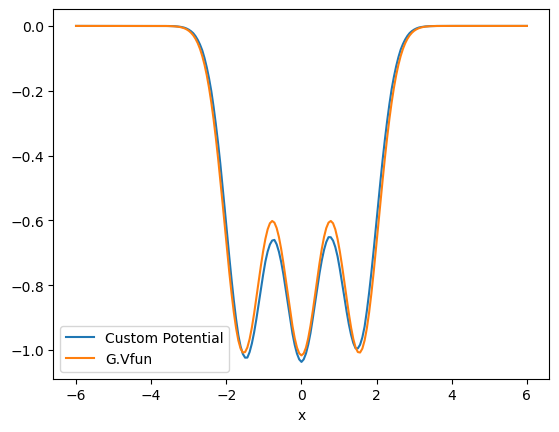

In [9]:
N = 201
x = np.linspace(-6, 6, N)
X = np.stack(
    [
        x.flatten(),
        np.zeros(N).flatten(),
        np.zeros(N).flatten(),
    ],
    axis=-1,
)
plt.plot(x, custom_potential(X), label="Custom Potential")
plt.plot(x, G.Vfun(x, 0, 0), label="G.Vfun")
plt.legend()
plt.xlabel("x")

Text(0.5, 0, 'y')

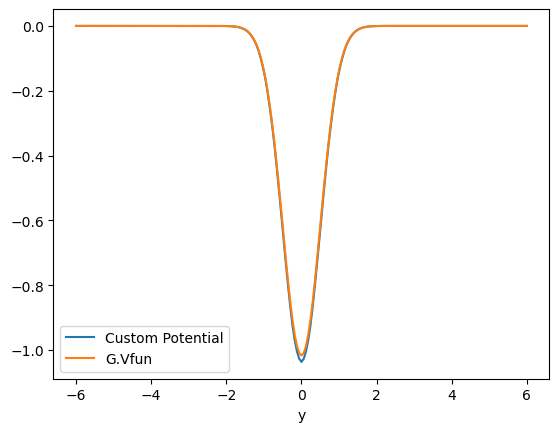

In [11]:
x = np.linspace(-6, 6, N)
X = np.stack(
    [
        np.zeros(N).flatten(),
        x.flatten(),
        np.zeros(N).flatten(),
    ],
    axis=-1,
)
plt.plot(x, custom_potential(X), label="Custom Potential")
plt.plot(x, G.Vfun(0, x, 0), label="G.Vfun")
plt.legend()
plt.xlabel("y")

Text(0.5, 0, 'z')

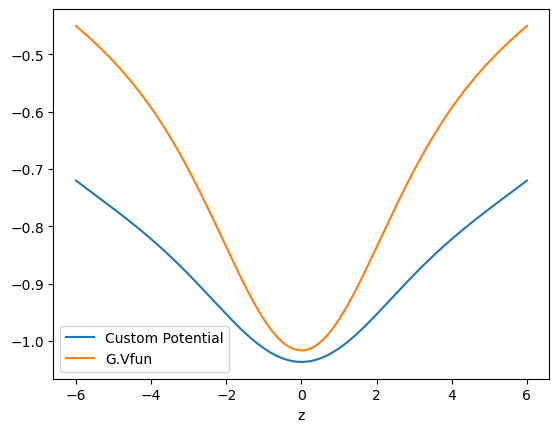

In [10]:
x = np.linspace(-6, 6, N)
X = np.stack(
    [
        np.zeros(N).flatten(),
        np.zeros(N).flatten(),
        x.flatten(),
    ],
    axis=-1,
)
plt.plot(x, custom_potential(X), label="Custom Potential")
plt.plot(x, G.Vfun(0, 0, x), label="G.Vfun")
plt.legend()
plt.xlabel("z")